In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [265]:
from pathlib import Path

print(Path.cwd())

c:\Users\Sreoshi\anomaly-detection\notebooks


In [266]:
#Why skiprows=1? We're telling Pandas to ignore the first metadata row and use the second row as the column header.

from pathlib import Path

data_path = Path("../data/raw/abohar_weather.csv")

print(data_path.resolve())
print(data_path.exists())

df = pd.read_csv(data_path, skiprows=2)

df.head()

C:\Users\Sreoshi\anomaly-detection\data\raw\abohar_weather.csv
True


,time,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01T00:00,3.0,96,1021.5
1,2020-01-01T01:00,2.5,97,1021.0
2,2020-01-01T02:00,1.9,98,1021.0
3,2020-01-01T03:00,1.7,98,1021.1
4,2020-01-01T04:00,1.5,99,1021.1


In [267]:
df = df.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature",
    "relative_humidity_2m": "humidity",
    "pressure_msl": "pressure"
})

df.head()

,timestamp,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01T00:00,3.0,96,1021.5
1,2020-01-01T01:00,2.5,97,1021.0
2,2020-01-01T02:00,1.9,98,1021.0
3,2020-01-01T03:00,1.7,98,1021.1
4,2020-01-01T04:00,1.5,99,1021.1


In [268]:
df.shape


(43848, 4)

In [269]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 43848 non-null  str    
 1   temperature_2m (°C)       43848 non-null  float64
 2   relative_humidity_2m (%)  43848 non-null  int64  
 3   pressure_msl (hPa)        43848 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 1.3 MB


In [270]:
# We want to know whether any sensor readings are missing.
df.isnull().sum()

timestamp                   0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
pressure_msl (hPa)          0
dtype: int64

In [271]:
df.describe()  #Basic stats

,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
count,43848.000000,43848.000000,43848.000000
mean,24.716366,58.486430,1008.306735
std,8.793384,22.909271,7.647973
min,1.500000,5.000000,989.200000
25%,18.000000,41.000000,1001.900000
50%,26.400000,60.000000,1008.000000
75%,31.300000,77.000000,1015.000000
max,47.300000,100.000000,1027.200000


In [272]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2020-01-01T00:00
End: 2024-12-31T23:00


In [273]:
df["timestamp"].duplicated().sum()    # Duplicate timestamps? 0 means no duplicates, which is good.

np.int64(0)

In [274]:
# Check the sampling interval, this is important for timeseries data.
df["timestamp"].diff().value_counts().head()  

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [ ]:
df = df.rename(columns={
    "temperature_2m (°C)": "temperature",
    "relative_humidity_2m (%)": "humidity",
    "pressure_msl (hPa)": "pressure"
})

df.columns

Index(['timestamp', 'temperature', 'humidity', 'pressure'], dtype='str')

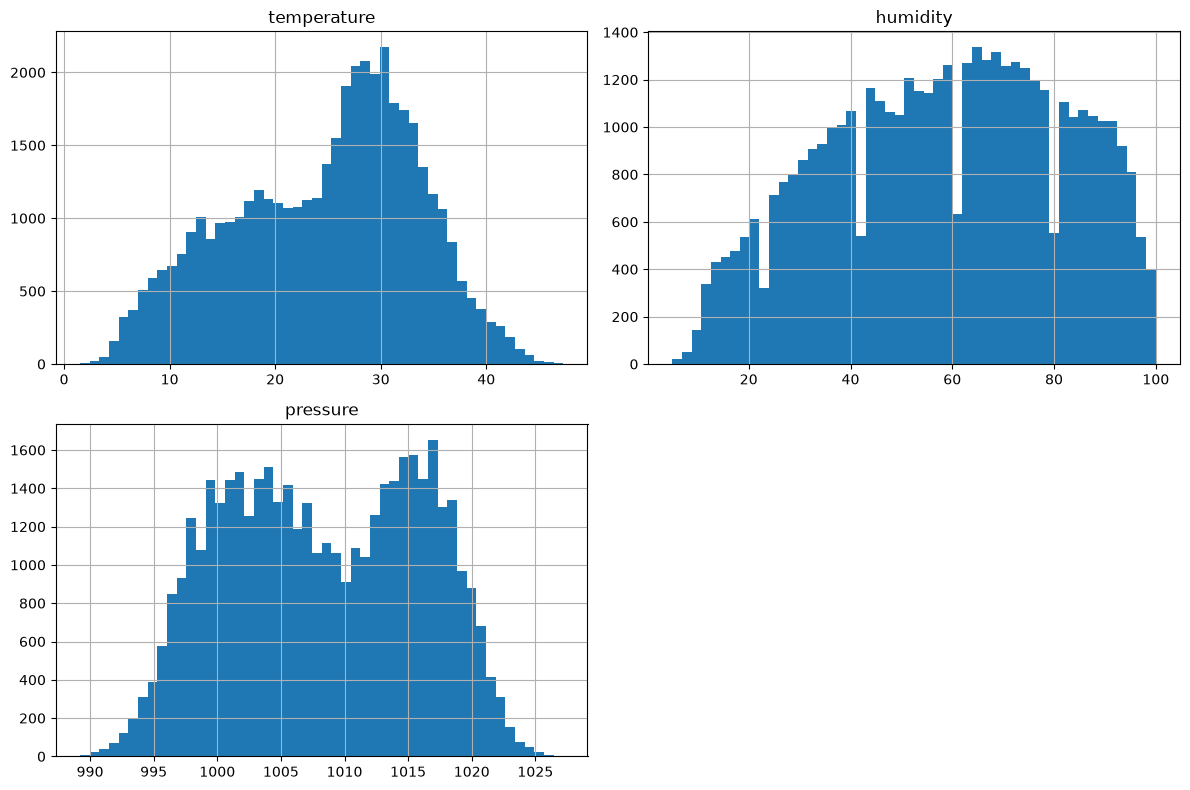

In [ ]:
df[["temperature", "humidity", "pressure"]].hist(
    bins=50,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

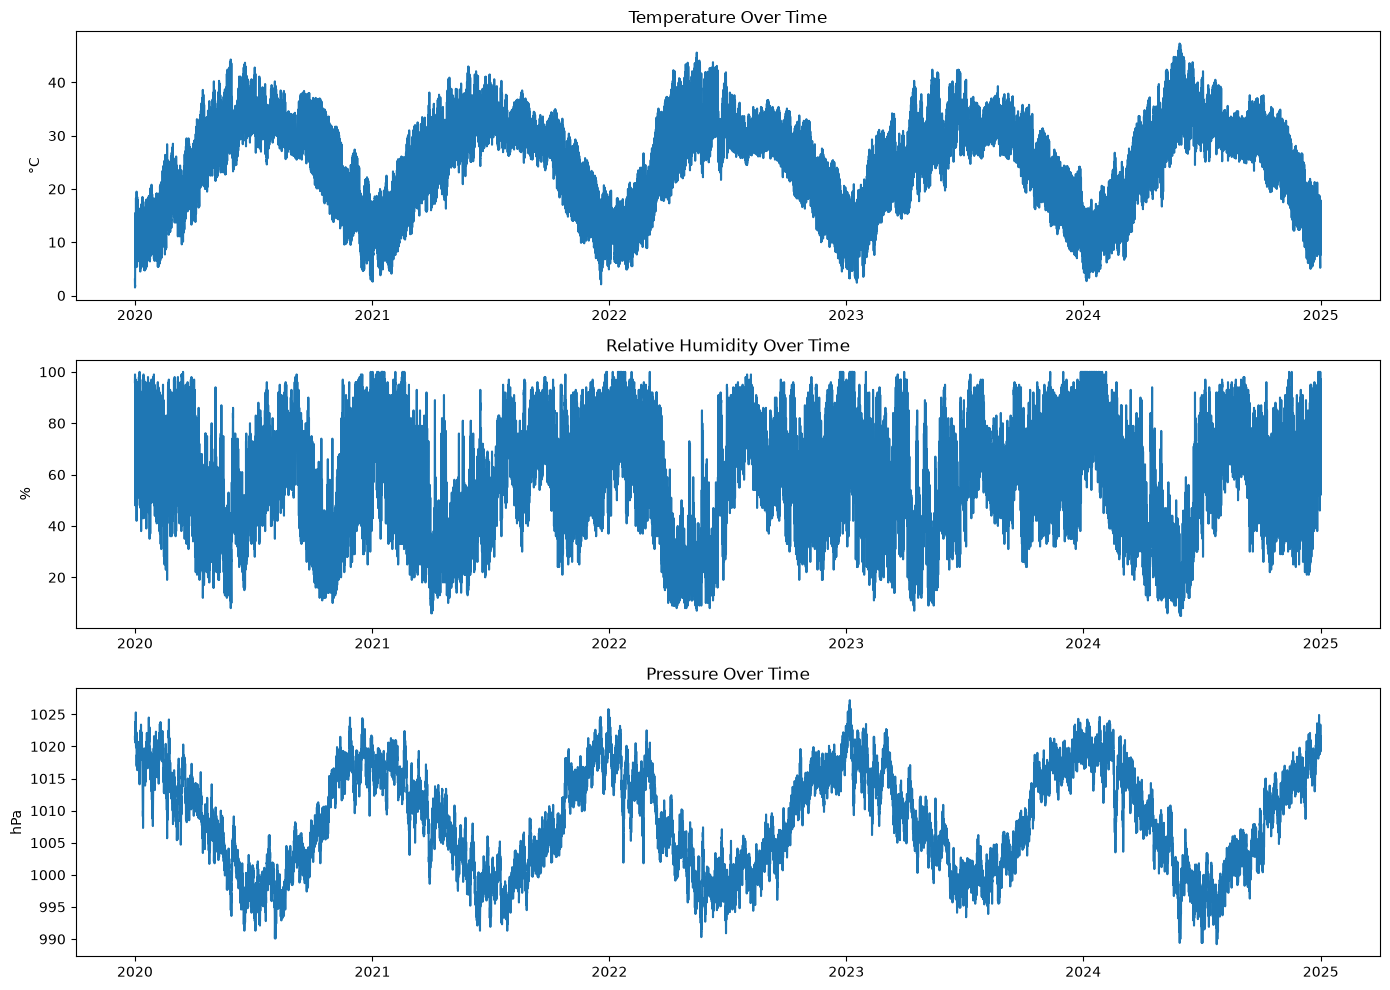

In [ ]:
# Actual sensor distributions, We are going to look at the actual time series before deciding what an anomaly looks like.

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df["timestamp"], df["temperature"])
axes[0].set_title("Temperature Over Time")
axes[0].set_ylabel("°C")

axes[1].plot(df["timestamp"], df["humidity"])
axes[1].set_title("Relative Humidity Over Time")
axes[1].set_ylabel("%")

axes[2].plot(df["timestamp"], df["pressure"])
axes[2].set_title("Pressure Over Time")
axes[2].set_ylabel("hPa")

plt.tight_layout()
plt.show()

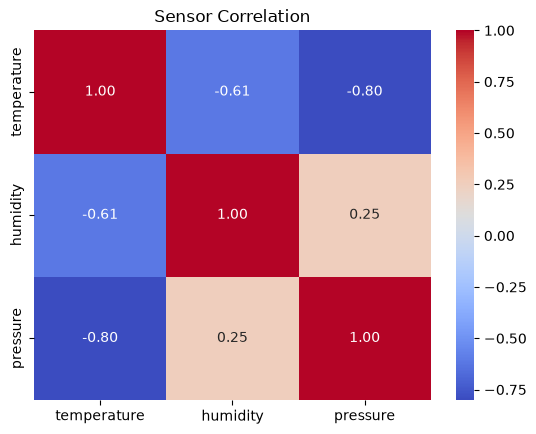

In [ ]:
corr = df[["temperature", "humidity", "pressure"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Sensor Correlation")
plt.show()

In [ ]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["year"] = df["timestamp"].dt.year

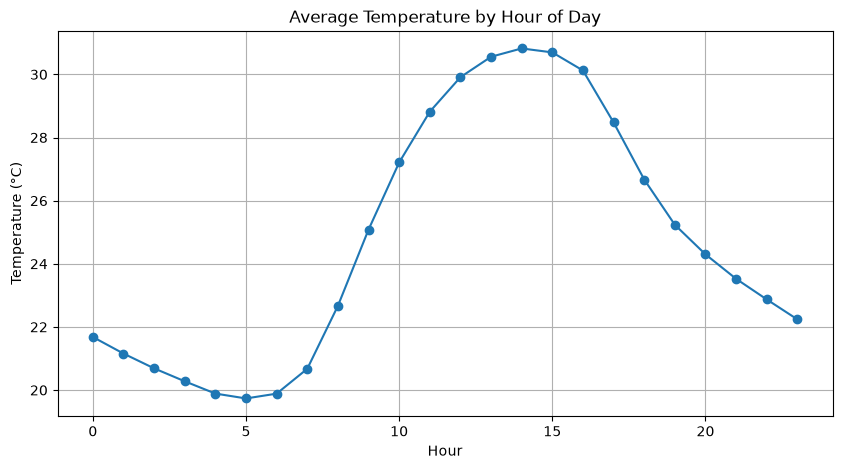

In [ ]:
hourly_temp = df.groupby("hour")["temperature"].mean()

hourly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

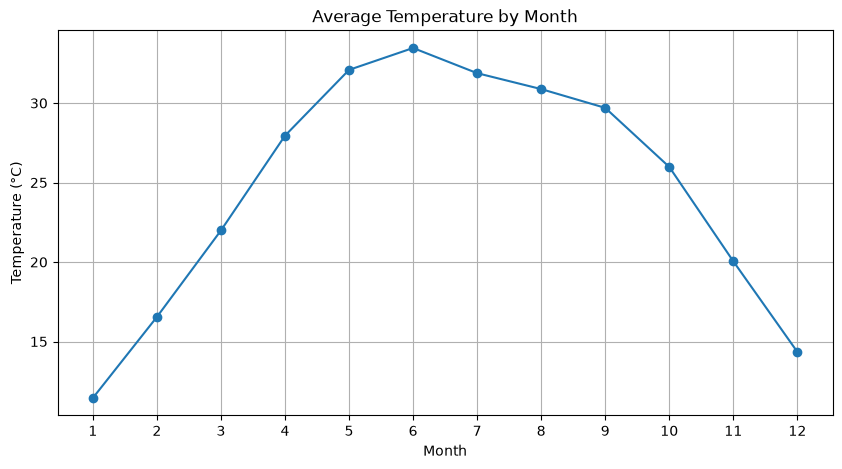

In [ ]:
monthly_temp = df.groupby("month")["temperature"].mean()

monthly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

In [ ]:
df[["temperature", "humidity", "pressure"]].corr()

,temperature,humidity,pressure
temperature,1.000000,-0.611447,-0.800485
humidity,-0.611447,1.000000,0.254298
pressure,-0.800485,0.254298,1.000000


In [ ]:
df = df.sort_values("timestamp").reset_index(drop=True)     # Sort by timestamp and reset index for time series analysis

In [ ]:
df["temperature_change"] = df["temperature"].diff()         #Sensor readings can be noisy, so we can look at the change in readings to identify anomalies.
df["humidity_change"] = df["humidity"].diff()
df["pressure_change"] = df["pressure"].diff()

In [ ]:
df["temperature_rolling_mean"] = (                         # Rolling mean can help smooth out short term fluctuations and highlight longer term trends or cycles.
    df["temperature"].rolling(24).mean()
)

df["temperature_rolling_std"] = (
    df["temperature"].rolling(24).std()
)

In [ ]:
# Why 24? because our data is hourly: 1 day = 24 observations
# So we ae asking: How unusual is this reading compared with the recent 24h behavior?

df["humidity_rolling_mean"] = (
    df["humidity"].rolling(24).mean()
)

df["humidity_rolling_std"] = (
    df["humidity"].rolling(24).std()
)

df["pressure_rolling_mean"] = (
    df["pressure"].rolling(24).mean()
)

df["pressure_rolling_std"] = (
    df["pressure"].rolling(24).std()
)

In [ ]:
#Local deviation from the rolling mean can help identify anomalies that are not just outliers but also unusual compared to recent trends.
df["temperature_deviation"] = (                               
    df["temperature"] - df["temperature_rolling_mean"]
)

df["humidity_deviation"] = (
    df["humidity"] - df["humidity_rolling_mean"]
)

df["pressure_deviation"] = (
    df["pressure"] - df["pressure_rolling_mean"]
)

In [ ]:
# notice that the first ~23 rows have NaN values for the rolling features. That's expected. We don't have 24 previous observations for the beginning of the dataset.

df.head(30)

,timestamp,temperature,humidity,pressure,hour,day,month,year,temperature_change,humidity_change,pressure_change,temperature_rolling_mean,temperature_rolling_std,humidity_rolling_mean,humidity_rolling_std,pressure_rolling_mean,pressure_rolling_std,temperature_deviation,humidity_deviation,pressure_deviation
0,2020-01-01 00:00:00,3.0,96,1021.5,0,1,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00,2.5,97,1021.0,1,1,1,2020,-0.5,1.0,-0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 02:00:00,1.9,98,1021.0,2,1,1,2020,-0.6,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 03:00:00,1.7,98,1021.1,3,1,1,2020,-0.2,0.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 04:00:00,1.5,99,1021.1,4,1,1,2020,-0.2,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2020-01-01 05:00:00,2.0,98,1021.4,5,1,1,2020,0.5,-1.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2020-01-01 06:00:00,1.9,98,1021.7,6,1,1,2020,-0.1,0.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2020-01-01 07:00:00,1.7,98,1022.2,7,1,1,2020,-0.2,0.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2020-01-01 08:00:00,3.6,94,1022.7,8,1,1,2020,1.9,-4.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2020-01-01 09:00:00,6.6,85,1023.3,9,1,1,2020,3.0,-9.0,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()  # see the  missing values in the rolling columns. Not filling them yet. We will handle that properly when we prepare the ML dataset.

timestamp                    0
temperature                  0
humidity                     0
pressure                     0
hour                         0
day                          0
month                        0
year                         0
temperature_change           1
humidity_change              1
pressure_change              1
temperature_rolling_mean    23
temperature_rolling_std     23
humidity_rolling_mean       23
humidity_rolling_std        23
pressure_rolling_mean       23
pressure_rolling_std        23
temperature_deviation       23
humidity_deviation          23
pressure_deviation          23
dtype: int64

In [ ]:
#z-score normalization is a common technique to standardize features by removing the mean and scaling to unit variance. This is particularly useful for anomaly detection, as it allows us to identify outliers based on how many standard deviations away they are from the mean.

from scipy.stats import zscore

df["temperature_z"] = zscore(df["temperature"])
df["humidity_z"] = zscore(df["humidity"])
df["pressure_z"] = zscore(df["pressure"])

In [ ]:
#checking the z-score values for the first few rows
df["zscore_anomaly"] = (
    (df["temperature_z"].abs() > 3) |
    (df["humidity_z"].abs() > 3) |
    (df["pressure_z"].abs() > 3)
)

In [ ]:
df["zscore_anomaly"].value_counts()

zscore_anomaly
False    43848
Name: count, dtype: int64

In [ ]:
df[df["zscore_anomaly"]][
    ["timestamp", "temperature", "humidity", "pressure",
     "temperature_z", "humidity_z", "pressure_z"]
].head(20)

,timestamp,temperature,humidity,pressure,temperature_z,humidity_z,pressure_z


In [ ]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

In [ ]:
temp_lower, temp_upper = iqr_bounds(df["temperature"])
hum_lower, hum_upper = iqr_bounds(df["humidity"])
pressure_lower, pressure_upper = iqr_bounds(df["pressure"])

print("Temperature:", temp_lower, "to", temp_upper)
print("Humidity:", hum_lower, "to", hum_upper)
print("Pressure:", pressure_lower, "to", pressure_upper)

Temperature: -1.9500000000000028 to 51.25
Humidity: -13.0 to 131.0
Pressure: 982.25 to 1034.65


In [ ]:
# checking the IQR bounds for the first few rows
df["iqr_anomaly"] = (
    (df["temperature"] < temp_lower) |
    (df["temperature"] > temp_upper) |
    (df["humidity"] < hum_lower) |
    (df["humidity"] > hum_upper) |
    (df["pressure"] < pressure_lower) |
    (df["pressure"] > pressure_upper)
)

In [ ]:
df["iqr_anomaly"].value_counts()

iqr_anomaly
False    43848
Name: count, dtype: int64

In [ ]:
print("Z-score anomalies:", df["zscore_anomaly"].sum())   # compare the two baselines
print("IQR anomalies:", df["iqr_anomaly"].sum())

Z-score anomalies: 0
IQR anomalies: 0


In [ ]:
pd.crosstab(                      # tells us how many anomalies were detected by both methods, and how many were unique to each method.
    df["zscore_anomaly"],
    df["iqr_anomaly"]
)

iqr_anomaly,False
zscore_anomaly,
False,43848


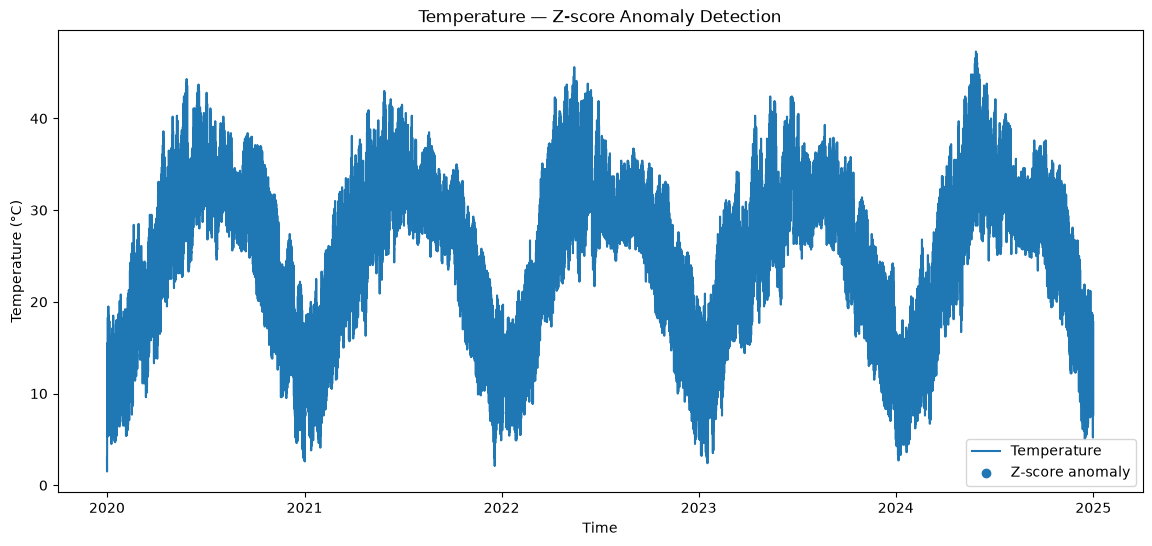

In [ ]:
plt.figure(figsize=(14, 6))        # visualizing the anomalies detected by the z-score method. This helps us understand how the anomalies are distributed over time and how they relate to the actual temperature readings.

plt.plot(
    df["timestamp"],
    df["temperature"],
    label="Temperature"
)

anomalies = df[df["zscore_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Z-score anomaly"
)

plt.title("Temperature — Z-score Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [ ]:
features = [
    "temperature",
    "humidity",
    "pressure",
    "hour",
    "month",
    "temperature_change",
    "humidity_change",
    "pressure_change",
    "temperature_rolling_mean",
    "temperature_rolling_std",
    "humidity_rolling_mean",
    "humidity_rolling_std",
    "pressure_rolling_mean",
    "pressure_rolling_std",
    "temperature_deviation",
    "humidity_deviation",
    "pressure_deviation"
]

In [ ]:
ml_df = df.dropna(subset=features).copy()          # remove rows with NaN values in the features we will use for ML. This is important because many ML algorithms cannot handle NaN values.

In [ ]:
print("Original rows:", len(df))
print("ML rows:", len(ml_df))

Original rows: 43848
ML rows: 43825


In [ ]:
X = ml_df[features]

In [ ]:
 # train Isolation forest model to detect anomalies in the sensor data. It is an unsupervised learning algorithm that identifies anomalies by isolating observations in the feature space.
import sys
print(sys.executable)

from sklearn.ensemble import IsolationForest
print("Isolation Forest is ready!")

c:\Users\Sreoshi\anomaly-detection\.venv\Scripts\python.exe
Isolation Forest is ready!


In [ ]:
model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

In [ ]:
ml_df["isolation_prediction"] = model.fit_predict(X)

In [ ]:
ml_df["isolation_anomaly"] = (
    ml_df["isolation_prediction"] == -1
)

In [ ]:
ml_df["isolation_prediction"] = model.fit_predict(X)

ml_df["isolation_anomaly"] = (
    ml_df["isolation_prediction"] == -1
)

In [ ]:
print("Isolation Forest anomalies:", ml_df["isolation_anomaly"].sum())

Isolation Forest anomalies: 5522


In [ ]:
print(ml_df["isolation_anomaly"].value_counts())

isolation_anomaly
False    38303
True      5522
Name: count, dtype: int64


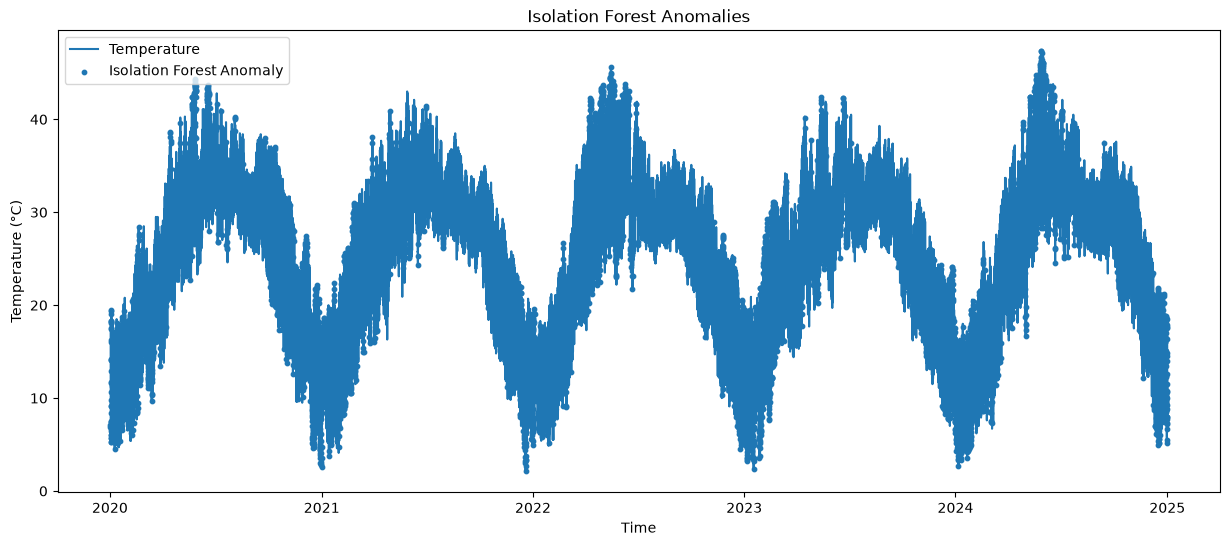

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_df["timestamp"],
    ml_df["temperature"],
    label="Temperature"
)

anomalies = ml_df[ml_df["isolation_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Isolation Forest Anomaly",
    s=10
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Isolation Forest Anomalies")
plt.legend()
plt.show()

In [ ]:
ml_df["anomaly_score"] = model.decision_function(X)

In [ ]:
ml_df["anomaly_score"].describe()

count    43825.000000
mean         0.036468
std          0.030488
min         -0.118312
25%          0.016968
50%          0.039996
75%          0.059527
max          0.106989
Name: anomaly_score, dtype: float64

In [ ]:
ml_df[
    ["timestamp", "temperature", "humidity", "pressure", "anomaly_score"]
].sort_values("anomaly_score").head(10)

,timestamp,temperature,humidity,pressure,anomaly_score
21562,2022-06-17 10:00:00,25.5,84,1002.5,-0.118312
39978,2024-07-23 18:00:00,28.8,87,994.6,-0.107931
39450,2024-07-01 18:00:00,29.9,82,991.9,-0.105307
4108,2020-06-20 04:00:00,28.0,73,1000.3,-0.099829
12413,2021-06-01 05:00:00,25.2,75,1000.7,-0.099340
4637,2020-07-12 05:00:00,27.5,85,996.7,-0.098480
39198,2024-06-21 06:00:00,24.5,92,999.9,-0.094822
18065,2022-01-22 17:00:00,12.9,94,1003.3,-0.094703
38677,2024-05-30 13:00:00,45.7,7,996.3,-0.094315
20967,2022-05-23 15:00:00,26.6,72,995.1,-0.093987


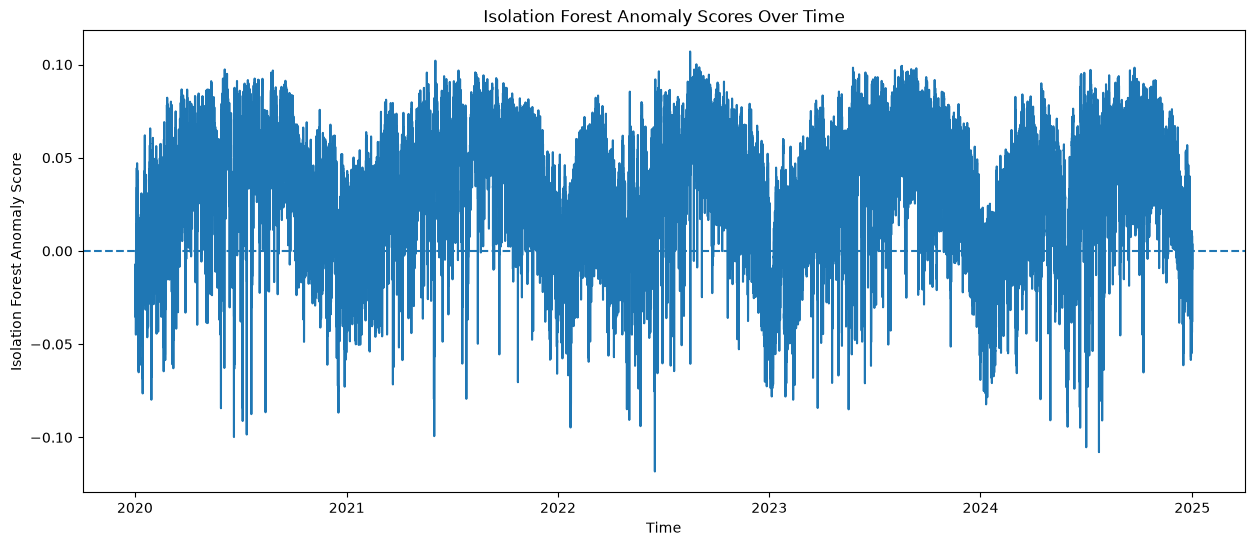

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_df["timestamp"],
    ml_df["anomaly_score"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Isolation Forest Anomaly Score")
plt.title("Isolation Forest Anomaly Scores Over Time")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Z-score": df.loc[ml_df.index, "zscore_anomaly"],
    "IQR": df.loc[ml_df.index, "iqr_anomaly"],
    "Isolation Forest": ml_df["isolation_anomaly"]
})

comparison.sum()

Z-score                0
IQR                    0
Isolation Forest    5522
dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler

autoencoder_features = [
    "temperature",
    "humidity",
    "pressure",
    "hour",
    "month",
    "temperature_change",
    "humidity_change",
    "pressure_change",
    "temperature_rolling_mean",
    "temperature_rolling_std",
    "humidity_rolling_mean",
    "humidity_rolling_std",
    "pressure_rolling_mean",
    "pressure_rolling_std",
    "temperature_deviation",
    "humidity_deviation",
    "pressure_deviation"
]

ae_df = df.dropna(subset=autoencoder_features).copy()

X_ae = ae_df[autoencoder_features]

print("Autoencoder rows:", len(ae_df))
print("Features:", X_ae.shape[1])

Autoencoder rows: 43825
Features: 17


In [ ]:
train_size = int(len(X_ae) * 0.7)
val_size = int(len(X_ae) * 0.15)

X_train = X_ae.iloc[:train_size]
X_val = X_ae.iloc[train_size:train_size + val_size]
X_test = X_ae.iloc[train_size + val_size:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (30677, 17)
Validation: (6573, 17)
Test: (6575, 17)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training mean:", X_train_scaled.mean())
print("Training std:", X_train_scaled.std())

Training mean: 5.510937026211347e-16
Training std: 1.0


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print("Train tensor:", X_train_tensor.shape)
print("Validation tensor:", X_val_tensor.shape)

Train tensor: torch.Size([30677, 17])
Validation tensor: torch.Size([6573, 17])


In [ ]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 12),
            nn.ReLU(),
            nn.Linear(12, 6),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(6, 12),
            nn.ReLU(),
            nn.Linear(12, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


model_ae = Autoencoder(input_dim=X_train_tensor.shape[1])

print(model_ae)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=17, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=6, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=6, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=17, bias=True)
  )
)


In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_ae.parameters(),
    lr=0.001
)

print("Autoencoder ready")

Autoencoder ready


In [ ]:
epochs = 30

train_losses = []
val_losses = []

for epoch in range(epochs):

    model_ae.train()
    train_loss = 0.0

    for (batch,) in train_loader:
        optimizer.zero_grad()

        reconstructed = model_ae(batch)
        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model_ae.eval()
    val_loss = 0.0

    with torch.no_grad():
        for (batch,) in val_loader:
            reconstructed = model_ae(batch)
            loss = criterion(reconstructed, batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch [1/30] Train Loss: 0.759201 Val Loss: 0.432258
Epoch [2/30] Train Loss: 0.338806 Val Loss: 0.274308
Epoch [3/30] Train Loss: 0.240140 Val Loss: 0.232259
Epoch [4/30] Train Loss: 0.221709 Val Loss: 0.217273
Epoch [5/30] Train Loss: 0.207911 Val Loss: 0.204385
Epoch [6/30] Train Loss: 0.193798 Val Loss: 0.190482
Epoch [7/30] Train Loss: 0.177498 Val Loss: 0.170159
Epoch [8/30] Train Loss: 0.158733 Val Loss: 0.150479
Epoch [9/30] Train Loss: 0.145643 Val Loss: 0.140691
Epoch [10/30] Train Loss: 0.138221 Val Loss: 0.136738
Epoch [11/30] Train Loss: 0.133587 Val Loss: 0.132042
Epoch [12/30] Train Loss: 0.130507 Val Loss: 0.128327
Epoch [13/30] Train Loss: 0.128380 Val Loss: 0.125730
Epoch [14/30] Train Loss: 0.126692 Val Loss: 0.128286
Epoch [15/30] Train Loss: 0.125424 Val Loss: 0.125871
Epoch [16/30] Train Loss: 0.124449 Val Loss: 0.124894
Epoch [17/30] Train Loss: 0.123902 Val Loss: 0.125046
Epoch [18/30] Train Loss: 0.123355 Val Loss: 0.122448
Epoch [19/30] Train Loss: 0.123218 Va

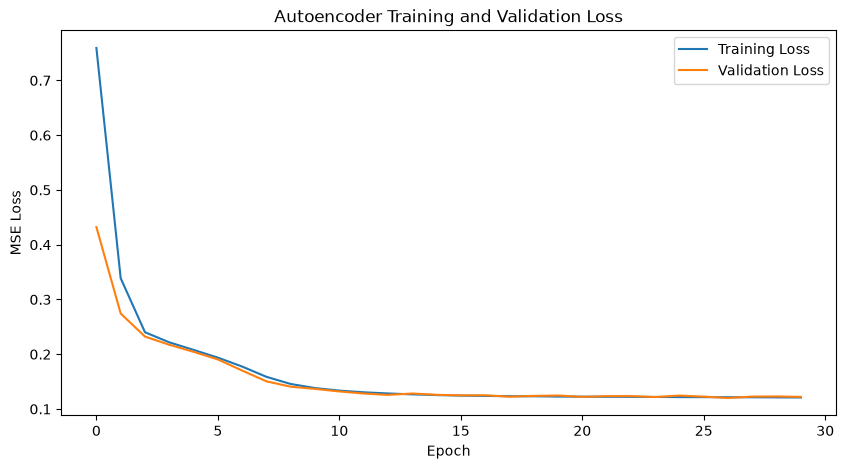

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
model_ae.eval()

with torch.no_grad():
    X_test_reconstructed = model_ae(X_test_tensor)

reconstruction_error = torch.mean(
    (X_test_tensor - X_test_reconstructed) ** 2,
    dim=1
).numpy()

print("Reconstruction errors:", len(reconstruction_error))
print("Minimum:", reconstruction_error.min())
print("Maximum:", reconstruction_error.max())
print("Mean:", reconstruction_error.mean())

Reconstruction errors: 6575
Minimum: 0.00483545
Maximum: 1.7423033
Mean: 0.1149731


In [ ]:
with torch.no_grad():
    X_val_reconstructed = model_ae(X_val_tensor)

val_reconstruction_error = torch.mean(
    (X_val_tensor - X_val_reconstructed) ** 2,
    dim=1
).numpy()

In [ ]:
threshold = np.percentile(val_reconstruction_error, 95)

print("Anomaly threshold:", threshold)

Anomaly threshold: 0.3190607


In [ ]:
test_anomaly = reconstruction_error > threshold

print("Autoencoder anomalies:", test_anomaly.sum())
print("Total test observations:", len(test_anomaly))

Autoencoder anomalies: 309
Total test observations: 6575


In [ ]:
test_anomaly = reconstruction_error > threshold

print("Autoencoder anomalies:", test_anomaly.sum())
print("Total test observations:", len(test_anomaly))
print("Anomaly percentage:", test_anomaly.mean() * 100)

Autoencoder anomalies: 309
Total test observations: 6575
Anomaly percentage: 4.699619771863118


In [ ]:
ae_results = ae_df.iloc[
    train_size + val_size:
].copy()

ae_results["reconstruction_error"] = reconstruction_error
ae_results["autoencoder_anomaly"] = test_anomaly

print(ae_results["autoencoder_anomaly"].value_counts())

autoencoder_anomaly
False    6266
True      309
Name: count, dtype: int64


In [ ]:
ae_results[
    [
        "timestamp",
        "temperature",
        "humidity",
        "pressure",
        "reconstruction_error"
    ]
].sort_values(
    "reconstruction_error",
    ascending=False
).head(10)

,timestamp,temperature,humidity,pressure,reconstruction_error
41824,2024-10-08 16:00:00,22.7,88,1013.4,1.742303
37554,2024-04-13 18:00:00,22.9,70,1011.1,1.588552
39182,2024-06-20 14:00:00,28.8,72,996.8,1.294663
39513,2024-07-04 09:00:00,28.8,83,1000.0,1.287772
39183,2024-06-20 15:00:00,35.5,49,994.3,1.163602
39978,2024-07-23 18:00:00,28.8,87,994.6,1.055593
37938,2024-04-29 18:00:00,29.5,17,1006.7,1.031560
43320,2024-12-10 00:00:00,11.3,70,1018.8,1.023231
37555,2024-04-13 19:00:00,21.7,84,1011.0,0.945072
40110,2024-07-29 06:00:00,27.8,94,999.2,0.920413


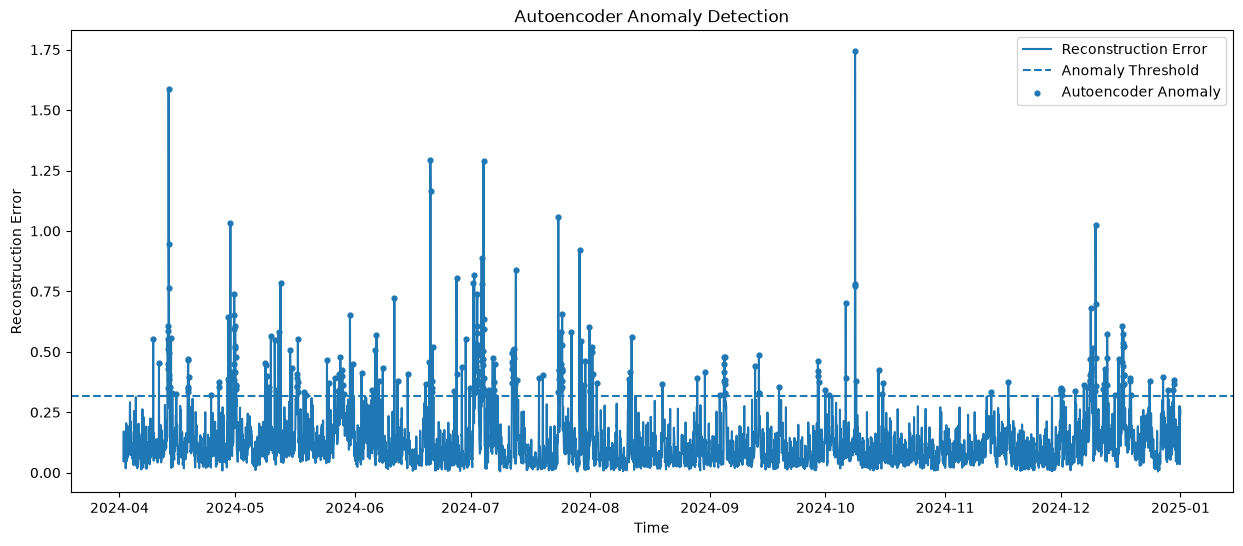

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    ae_results["timestamp"],
    ae_results["reconstruction_error"],
    label="Reconstruction Error"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Anomaly Threshold"
)

anomalies = ae_results[ae_results["autoencoder_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["reconstruction_error"],
    label="Autoencoder Anomaly",
    s=12
)

plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.title("Autoencoder Anomaly Detection")
plt.legend()
plt.show()

In [ ]:
print("Autoencoder anomalies:", ae_results["autoencoder_anomaly"].sum())
print(
    "Anomaly percentage:",
    ae_results["autoencoder_anomaly"].mean() * 100
)

Autoencoder anomalies: 309
Anomaly percentage: 4.699619771863118


In [ ]:
# Z-score baseline
from scipy.stats import zscore

sensor_cols = ["temperature", "humidity", "pressure"]

z_scores = ml_df[sensor_cols].apply(zscore)

ml_df["zscore_anomaly"] = (z_scores.abs() > 3).any(axis=1)


# IQR baseline
iqr_anomaly = pd.Series(False, index=ml_df.index)

for col in sensor_cols:
    Q1 = ml_df[col].quantile(0.25)
    Q3 = ml_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_anomaly |= (
        (ml_df[col] < lower) |
        (ml_df[col] > upper)
    )

ml_df["iqr_anomaly"] = iqr_anomaly

print("Z-score anomalies:", ml_df["zscore_anomaly"].sum())
print("IQR anomalies:", ml_df["iqr_anomaly"].sum())
print("Isolation Forest anomalies:", ml_df["isolation_anomaly"].sum())

Z-score anomalies: 0
IQR anomalies: 0
Isolation Forest anomalies: 5522


In [ ]:
comparison = ml_df[
    [
        "timestamp",
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly"
    ]
].copy()

comparison = comparison.merge(
    ae_results[
        [
            "timestamp",
            "reconstruction_error",
            "autoencoder_anomaly"
        ]
    ],
    on="timestamp",
    how="left"
)

print(comparison.columns.tolist())

['timestamp', 'zscore_anomaly', 'iqr_anomaly', 'isolation_anomaly', 'reconstruction_error', 'autoencoder_anomaly']


In [ ]:
print(
    comparison[
        [
            "zscore_anomaly",
            "iqr_anomaly",
            "isolation_anomaly",
            "autoencoder_anomaly"
        ]
    ].sum()
)

zscore_anomaly            0
iqr_anomaly               0
isolation_anomaly      5522
autoencoder_anomaly     309
dtype: object


In [ ]:
print(ml_df["zscore_anomaly"].value_counts(dropna=False))
print()
print(ml_df["iqr_anomaly"].value_counts(dropna=False))

zscore_anomaly
False    43825
Name: count, dtype: int64

iqr_anomaly
False    43825
Name: count, dtype: int64


In [ ]:
test_comparison = comparison[
    comparison["autoencoder_anomaly"].notna()
].copy()

print("Common comparison observations:", len(test_comparison))

Common comparison observations: 6575


In [ ]:
method_counts = test_comparison[
    [
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly",
        "autoencoder_anomaly"
    ]
].sum()

print(method_counts)

zscore_anomaly           0
iqr_anomaly              0
isolation_anomaly      757
autoencoder_anomaly    309
dtype: object


In [ ]:
test_comparison["methods_detecting"] = test_comparison[
    [
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly",
        "autoencoder_anomaly"
    ]
].sum(axis=1)

print(
    test_comparison["methods_detecting"]
    .value_counts()
    .sort_index()
)

methods_detecting
0    5672
1     740
2     163
Name: count, dtype: int64


In [ ]:
ml_overlap = test_comparison[
    (test_comparison["isolation_anomaly"]) &
    (test_comparison["autoencoder_anomaly"])
]

print("Detected by both ML methods:", len(ml_overlap))

Detected by both ML methods: 163


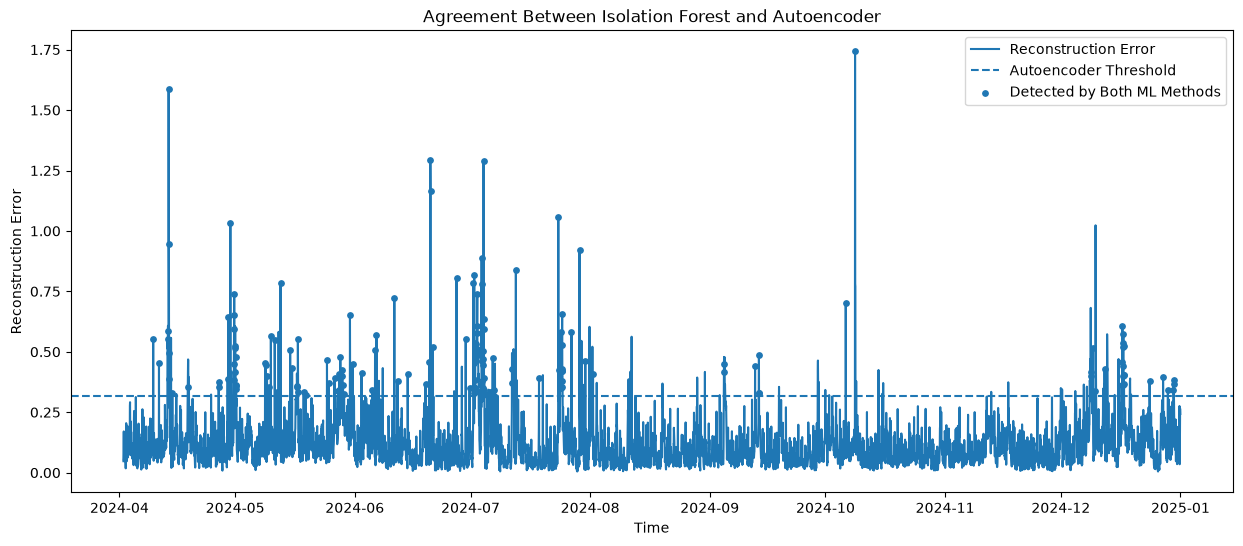

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_comparison["timestamp"],
    test_comparison["reconstruction_error"],
    label="Reconstruction Error"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Autoencoder Threshold"
)

plt.scatter(
    ml_overlap["timestamp"],
    ml_overlap["reconstruction_error"],
    s=15,
    label="Detected by Both ML Methods"
)

plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.title("Agreement Between Isolation Forest and Autoencoder")
plt.legend()
plt.show()

In [ ]:
scoring_df = test_comparison[                               #common observations for scoring, including the timestamp, anomaly flags from both ML methods, and the reconstruction error from the autoencoder. This will allow us to analyze and compare the performance of the two methods on the same set of observations.
    [
        "timestamp",
        "isolation_anomaly",
        "autoencoder_anomaly",
        "reconstruction_error"
    ]
].copy()

# Add Isolation Forest score
scoring_df = scoring_df.merge(
    ml_df[
        ["timestamp", "anomaly_score"]
    ],
    on="timestamp",
    how="left"
)

print("Scoring observations:", len(scoring_df))
scoring_df.head()

Scoring observations: 6575


,timestamp,isolation_anomaly,autoencoder_anomaly,reconstruction_error,anomaly_score
0,2024-04-02 01:00:00,False,False,0.047418,0.052995
1,2024-04-02 02:00:00,False,False,0.081883,0.030158
2,2024-04-02 03:00:00,False,False,0.170637,0.037530
3,2024-04-02 04:00:00,False,False,0.050013,0.065344
4,2024-04-02 05:00:00,False,False,0.063720,0.072308


In [ ]:
scoring_df["isolation_score"] = (                #convert Isolation Forest anomaly scores to percentile ranks. This helps in comparing the severity of anomalies detected by the Isolation Forest model.
    1 - scoring_df["anomaly_score"].rank(pct=True)
)

In [ ]:
scoring_df["autoencoder_score"] = (                   # convert reconstruction errors to percentile ranks
    scoring_df["reconstruction_error"].rank(pct=True)
)

In [ ]:
scoring_df["combined_anomaly_score"] = (  #create a combined anomaly score by averaging the Isolation Forest and Autoencoder scores. This provides a unified metric for anomaly detection, leveraging the strengths of both methods.
    0.5 * scoring_df["isolation_score"] +
    0.5 * scoring_df["autoencoder_score"]
)

In [ ]:
scoring_df["combined_anomaly_score"].describe() #check it

count    6575.000000
mean        0.500000
std         0.250782
min         0.005323
25%         0.294563
50%         0.493840
75%         0.699544
max         0.999544
Name: combined_anomaly_score, dtype: float64

In [ ]:
def classify_severity(score):      # create severity levels based on the combined anomaly score, helps in prioritizing anomalies for further investigation or action.
    if score >= 0.90:
        return "High"
    elif score >= 0.75:
        return "Medium"
    else:
        return "Low"


scoring_df["severity"] = (
    scoring_df["combined_anomaly_score"]
    .apply(classify_severity)
)

In [ ]:
print(scoring_df["severity"].value_counts())

severity
Low       5293
Medium     868
High       414
Name: count, dtype: int64


In [ ]:
top_anomalies = scoring_df.sort_values(           # strongest anomalies based on the combined anomaly score. 
    "combined_anomaly_score",        
    ascending=False
)

top_anomalies[
    [
        "timestamp",
        "isolation_score",
        "autoencoder_score",
        "combined_anomaly_score",
        "severity"
    ]
].head(10)

,timestamp,isolation_score,autoencoder_score,combined_anomaly_score,severity
2705,2024-07-23 18:00:00,0.999848,0.999240,0.999544,High
1909,2024-06-20 14:00:00,0.998327,0.999696,0.999011,High
2837,2024-07-29 06:00:00,0.999240,0.998631,0.998935,High
281,2024-04-13 18:00:00,0.997871,0.999848,0.998859,High
2177,2024-07-01 18:00:00,0.999696,0.997871,0.998783,High
2240,2024-07-04 09:00:00,0.996654,0.999544,0.998099,High
689,2024-04-30 18:00:00,0.999087,0.996806,0.997947,High
4551,2024-10-08 16:00:00,0.995285,1.000000,0.997643,High
2228,2024-07-03 21:00:00,0.996502,0.998479,0.997490,High
1409,2024-05-30 18:00:00,0.998631,0.995741,0.997186,High


In [ ]:
weather_values = ae_df[               # weather values corresponding to the top anomalies for context. This helps us understand the environmental conditions during the detected anomalies.
    [
        "timestamp",
        "temperature",
        "humidity",
        "pressure"
    ]
].copy()

scoring_df = scoring_df.merge(
    weather_values,
    on="timestamp",
    how="left"
)

print(scoring_df.shape)
scoring_df.head()

(6575, 12)


,timestamp,isolation_anomaly,autoencoder_anomaly,reconstruction_error,anomaly_score,isolation_score,autoencoder_score,combined_anomaly_score,severity,temperature,humidity,pressure
0,2024-04-02 01:00:00,False,False,0.047418,0.052995,0.393156,0.230722,0.311939,Low,17.2,64,1008.3
1,2024-04-02 02:00:00,False,False,0.081883,0.030158,0.664335,0.481065,0.572700,Low,16.2,70,1007.8
2,2024-04-02 03:00:00,False,False,0.170637,0.037530,0.588441,0.818859,0.703650,Low,18.1,59,1007.4
3,2024-04-02 04:00:00,False,False,0.050013,0.065344,0.201521,0.253840,0.227681,Low,18.1,59,1007.1
4,2024-04-02 05:00:00,False,False,0.063720,0.072308,0.118327,0.354829,0.236578,Low,18.2,58,1007.2


In [ ]:
# Add the original anomaly flags keep the statistical methods available in the final dataset too:

baseline_flags = ml_df[
    [
        "timestamp",
        "zscore_anomaly",
        "iqr_anomaly"
    ]
].copy()

scoring_df = scoring_df.merge(
    baseline_flags,
    on="timestamp",
    how="left"
)

In [ ]:
# Add a final anomaly flag, we need a simple decision that the future API/dashboard can use.
scoring_df["final_anomaly"] = (
    scoring_df["isolation_anomaly"] |
    scoring_df["autoencoder_anomaly"]
)

In [ ]:
print("Final anomalies:", scoring_df["final_anomaly"].sum())
print("Total observations:", len(scoring_df))
print(
    "Final anomaly percentage:",
    scoring_df["final_anomaly"].mean() * 100
)

Final anomalies: 903
Total observations: 6575
Final anomaly percentage: 13.73384030418251


In [ ]:
# inspect the top anomalies based on the combined anomaly score and their corresponding weather values.
final_columns = [
    "timestamp",
    "temperature",
    "humidity",
    "pressure",
    "isolation_score",
    "autoencoder_score",
    "combined_anomaly_score",
    "severity",
    "final_anomaly"
]

scoring_df[
    final_columns
].sort_values(
    "combined_anomaly_score",
    ascending=False
).head(20)

,timestamp,temperature,humidity,pressure,isolation_score,autoencoder_score,combined_anomaly_score,severity,final_anomaly
2705,2024-07-23 18:00:00,28.8,87,994.6,0.999848,0.999240,0.999544,High,True
1909,2024-06-20 14:00:00,28.8,72,996.8,0.998327,0.999696,0.999011,High,True
2837,2024-07-29 06:00:00,27.8,94,999.2,0.999240,0.998631,0.998935,High,True
281,2024-04-13 18:00:00,22.9,70,1011.1,0.997871,0.999848,0.998859,High,True
2177,2024-07-01 18:00:00,29.9,82,991.9,0.999696,0.997871,0.998783,High,True
2240,2024-07-04 09:00:00,28.8,83,1000.0,0.996654,0.999544,0.998099,High,True
689,2024-04-30 18:00:00,29.4,23,1002.8,0.999087,0.996806,0.997947,High,True
4551,2024-10-08 16:00:00,22.7,88,1013.4,0.995285,1.000000,0.997643,High,True
2228,2024-07-03 21:00:00,34.1,66,995.5,0.996502,0.998479,0.997490,High,True
1409,2024-05-30 18:00:00,42.6,5,995.6,0.998631,0.995741,0.997186,High,True


In [ ]:
# save the final scoring dataframe to a CSV file for further analysis or reporting.
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
output_path = processed_dir / "weather_anomaly_scores.csv"

scoring_df.to_csv(
    output_path,
    index=False
)

print("Saved to:", output_path.resolve())

Saved to: C:\Users\Sreoshi\anomaly-detection\data\processed\weather_anomaly_scores.csv
